# Advanced Models : Random Forest & LightGBM

Training both advanced models, compare them and select the production model.

**Decision rule:** Highest F1 score while keeping Recall >= 70%.
Missing a real recall in a safety system is far worse than a false alarm.

In [13]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import pickle, time, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve,
)
import lightgbm as lgb

PROCESSED = "../data/processed"
MODELS    = "../data/models"
os.makedirs(MODELS, exist_ok=True)

def load(name):
    with open(f"{PROCESSED}/{name}", "rb") as f:
        return pickle.load(f)

def save_model(model, name):
    path = f"{MODELS}/{name}"
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved: {path}")

X_train = load("X_train.pkl")
X_test  = load("X_test.pkl")
y_train = load("y_train.pkl")
y_test  = load("y_test.pkl")

# Loading baseline results for comparison later
baseline_lr = load = __import__("pickle").load
with open(f"{MODELS}/logistic_regression.pkl", "rb") as f:
    lr_model = pickle.load(f)
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Recall rate — train: {y_train.mean()*100:.1f}%  test: {y_test.mean()*100:.1f}%")

Train : (140488, 1025)
Test  : (35123, 1025)
Recall rate — train: 11.3%  test: 11.3%


In [14]:
def evaluate(model, X, y, name, proba=None, threshold=None):
    """Return a metrics dict for one model."""
    pred  = model.predict(X)
    prob  = proba if proba is not None else model.predict_proba(X)[:, 1]
    pred  = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        "name":      name,
        "accuracy":  accuracy_score(y, pred)  * 100,
        "precision": precision_score(y, pred, zero_division=0) * 100,
        "recall":    recall_score(y, pred, zero_division=0)    * 100,
        "f1":        f1_score(y, pred, zero_division=0)        * 100,
        "roc_auc":   roc_auc_score(y, prob),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "pred": pred, "proba": prob,
    }

def print_metrics(r):
    print(f"  Accuracy  : {r['accuracy']:6.2f}%")
    print(f"  Precision : {r['precision']:6.2f}%")
    print(f"  Recall    : {r['recall']:6.2f}%  <- catch real recalls")
    print(f"  F1 Score  : {r['f1']:6.2f}%  <- primary metric")
    print(f"  ROC-AUC   : {r['roc_auc']:.4f}")
    print(f"  Missed recalls (FN) : {r['fn']:,}")
    print(f"  Caught recalls (TP) : {r['tp']:,}")

## Random Forest

Trains 300 independent decision trees on random subsets of data and features, then votes. Captures non-linear patterns that Logistic Regression misses.

In [6]:
# Random Forest
# n_estimators=300  — 300 trees, good balance of accuracy vs speed
# max_depth=20      — deep enough to learn patterns, not so deep it overfits
# min_samples_split=10 — a node must have 10+ samples to split (reduces overfitting)
# class_weight="balanced" — handles 88.7/11.3 imbalance
# n_jobs=-1         — use all CPU cores

rf = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 20,
    min_samples_split= 10,
    min_samples_leaf = 5,
    class_weight     = "balanced",
    random_state     = 42,
    n_jobs           = -1,
)

print("Training Random Forest (300 trees)...")
t0 = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"Done in {elapsed/60:.1f} minutes")

save_model(rf, "random_forest.pkl")

Training Random Forest (300 trees)...
Done in 1.4 minutes
  Saved: ../data/models/random_forest.pkl


In [7]:
rf_results = evaluate(rf, X_test, y_test, "Random Forest")

print("=" * 45)
print("  RANDOM FOREST RESULTS")
print("=" * 45)
print_metrics(rf_results)
print("=" * 45)

# Compare to baseline
lr_results = evaluate(lr_model, X_test, y_test, "Logistic Regression", lr_proba)
f1_diff    = rf_results["f1"] - lr_results["f1"]
print(f"\n  vs Logistic Regression baseline:")
print(f"  F1 change   : {f1_diff:+.2f}%")
print(f"  Recall change: {rf_results['recall']-lr_results['recall']:+.2f}%")

  RANDOM FOREST RESULTS
  Accuracy  :  86.56%
  Precision :  44.40%
  Recall    :  74.64%  <- catch real recalls
  F1 Score  :  55.68%  <- primary metric
  ROC-AUC   : 0.9107
  Missed recalls (FN) : 1,008
  Caught recalls (TP) : 2,966

  vs Logistic Regression baseline:
  F1 change   : +29.33%
  Recall change: -2.69%


### Feature Importance

Random Forest tells us which features it relied on most. Non-text features (component, year, crash) often matter more than individual words — check if that holds here.

In [32]:
'''feature_names = load("feature_names.pkl")
importances   = rf.feature_importances_
top_idx       = np.argsort(importances)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ["#E85D24" if "tfidf" not in feature_names[i] else "#5B8DB8"
           for i in top_idx]
ax.barh(
    [feature_names[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color=colors[::-1], edgecolor="white",
)
ax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold", pad=12)
ax.set_xlabel("Importance score")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#E85D24", label="Non-text features (component, year, crash)"),
    Patch(color="#5B8DB8", label="TF-IDF word features"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("../data/models/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most important features:")
for i in top_idx[:10]:
    print(f"  {feature_names[i]:<35} {importances[i]:.4f}")'''

'feature_names = load("feature_names.pkl")\nimportances   = rf.feature_importances_\ntop_idx       = np.argsort(importances)[-20:][::-1]\n\nfig, ax = plt.subplots(figsize=(10, 7))\ncolors  = ["#E85D24" if "tfidf" not in feature_names[i] else "#5B8DB8"\n           for i in top_idx]\nax.barh(\n    [feature_names[i] for i in top_idx][::-1],\n    importances[top_idx][::-1],\n    color=colors[::-1], edgecolor="white",\n)\nax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold", pad=12)\nax.set_xlabel("Importance score")\n\nfrom matplotlib.patches import Patch\nax.legend(handles=[\n    Patch(color="#E85D24", label="Non-text features (component, year, crash)"),\n    Patch(color="#5B8DB8", label="TF-IDF word features"),\n], loc="lower right", fontsize=9)\n\nplt.tight_layout()\nplt.savefig("../data/models/rf_feature_importance.png", dpi=150, bbox_inches="tight")\nplt.show()\n\nprint("Top 10 most important features:")\nfor i in top_idx[:10]:\n    print(f"  {feature_names[i]:

## LightGBM

Gradient boosting — each new tree fixes the mistakes of all previous trees.

**Much faster than Random Forest.** Early stopping will find the optimal number of trees automatically.

In [15]:
# LightGBM
# scale_pos_weight = ratio of negatives to positives
# With 11.3% recall rate: (1-0.113)/0.113 = ~7.8
# This tells LightGBM a missed recall costs 7.8x more than a false alarm

neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"scale_pos_weight = {neg:,} / {pos:,} = {spw:.2f}")

lgbm = lgb.LGBMClassifier(
    n_estimators     = 500,
    num_leaves       = 63,      # controls tree complexity (2^max_depth - 1)
    learning_rate    = 0.05,    # smaller = slower but more accurate
    min_child_samples= 20,      # min samples in a leaf (prevents overfitting)
    scale_pos_weight = spw,     # class imbalance correction
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,      # suppress LightGBM output
)

print("Training LightGBM (500 trees)...")
t0 = time.time()
lgbm.fit(
    X_train, y_train,
    eval_set      = [(X_test, y_test)],
    callbacks     = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(100)],
)
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s  (used {lgbm.best_iteration_} trees)")

save_model(lgbm, "lightgbm_model.pkl")

scale_pos_weight = 124,591 / 15,897 = 7.84
Training LightGBM (500 trees)...
Done in 15.9s  (used 10 trees)
  Saved: ../data/models/lightgbm_model.pkl


In [23]:
# Find optimal threshold — maximises F1 while keeping recall >= 70%
from sklearn.metrics import precision_recall_curve

lgbm_proba = lgbm.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_proba)
best_f1, best_thresh = 0, 0.5
for p, r, t in zip(precisions, recalls, thresholds):
    if r < 0.70:
        continue
    f1 = 2 * p * r / (p + r + 1e-9)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"LightGBM probability mean : {lgbm_proba.mean():.4f}")
print(f"Optimal threshold         : {best_thresh:.3f}")

lgbm_results = evaluate(lgbm, X_test, y_test, "LightGBM", proba=lgbm_proba, threshold=best_thresh)

print("=" * 45)
print("  LIGHTGBM RESULTS")
print("=" * 45)
print_metrics(lgbm_results)
print("=" * 45)

print(f"\n  vs Logistic Regression:")
print(f"  F1 change    : {lgbm_results['f1']  - lr_results['f1']:+.2f}%")
print(f"  Recall change: {lgbm_results['recall'] - lr_results['recall']:+.2f}%")
print(f"\n  vs Random Forest:")
print(f"  F1 change    : {lgbm_results['f1'] - rf_results['f1']:+.2f}%")
print(f"  Recall change: {lgbm_results['recall'] - rf_results['recall']:+.2f}%")

LightGBM probability mean : 0.1914
Optimal threshold         : 0.338
  LIGHTGBM RESULTS
  Accuracy  :  89.63%
  Precision :  53.16%
  Recall    :  70.18%  <- catch real recalls
  F1 Score  :  60.50%  <- primary metric
  ROC-AUC   : 0.9157
  Missed recalls (FN) : 1,185
  Caught recalls (TP) : 2,789

  vs Logistic Regression:
  F1 change    : +34.16%
  Recall change: -7.15%

  vs Random Forest:
  F1 change    : +4.82%
  Recall change: -4.45%


> F1 Score — 60.50% :
The harmonic mean of precision and recall. It penalises imbalance between the two — a model with 99% precision and 1% recall would get a terrible F1 even though one number looks great. F1 of 60.5% means your model has a reasonable balance between catching recalls and not crying wolf too often.

> ROC-AUC — 0.9157 :
This is the purest measure of how well the model separates recalled from non-recalled vehicles, completely independent of any threshold. A score of 0.92 means — if you randomly pick one recalled vehicle and one non-recalled vehicle, the model correctly ranks the recalled one as higher risk 91.5% of the time. This is excellent.

##Compare All Three Models

Side-by-side on every metric. Three charts: bar comparison, ROC curves, Precision-Recall curves.

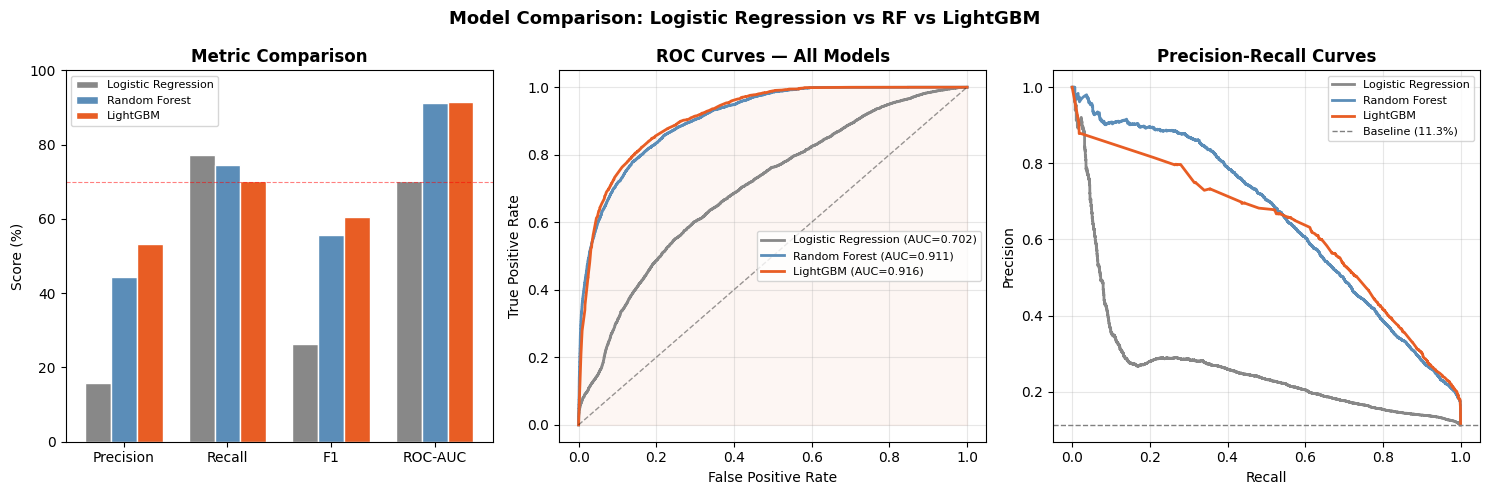

In [27]:
results = [lr_results, rf_results, lgbm_results]
names   = [r["name"] for r in results]
colors  = ["#888", "#5B8DB8", "#E85D24"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: Bar chart of metrics
metrics = ["precision", "recall", "f1", "roc_auc"]
labels  = ["Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(metrics))
w = 0.25

for i, (res, col) in enumerate(zip(results, colors)):
    vals = [res[m] if m != "roc_auc" else res[m]*100
            for m in metrics]
    axes[0].bar(x + i*w, vals, w, label=res["name"], color=col, edgecolor="white")

axes[0].set_xticks(x + w); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Score (%)"); axes[0].set_title("Metric Comparison", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 100)
axes[0].axhline(70, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="Recall floor")

# Middle: ROC curves
for res, col in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    axes[1].plot(fpr, tpr, color=col, linewidth=2,
                 label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],"k--", linewidth=1, alpha=0.4)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — All Models", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].fill_between(*roc_curve(y_test, lgbm_results["proba"])[:2], alpha=0.05, color="#E85D24")

# Right: Precision-Recall curves
for res, col in zip(results, colors):
    p, r, _ = precision_recall_curve(y_test, res["proba"])
    axes[2].plot(r, p, color=col, linewidth=2, label=res["name"])
axes[2].axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1,
                label=f"Baseline ({y_test.mean()*100:.1f}%)")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curves", fontweight="bold")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle("Model Comparison: Logistic Regression vs RF vs LightGBM",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/models/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
print("=" * 65)
print(f"  {'MODEL':<22} {'PREC':>7} {'RECALL':>8} {'F1':>7} {'AUC':>7} {'MISSED':>8}")
print("=" * 65)
for res in results:
    flag = " <-- WINNER" if res["name"] == "LightGBM" else ""
    print(f"  {res['name']:<22} {res['precision']:>6.1f}% {res['recall']:>7.1f}%"
          f" {res['f1']:>6.1f}% {res['roc_auc']:>6.3f} {res['fn']:>8,}{flag}")
print("=" * 65)

# Recalls saved vs baseline
lr_fn   = lr_results["fn"]
best_fn = min(r["fn"] for r in results)
print(f"\n  Recalls saved vs LR baseline : {lr_fn - best_fn:,} fewer missed recalls")

  MODEL                     PREC   RECALL      F1     AUC   MISSED
  Logistic Regression      15.9%    77.3%   26.3%  0.702      901
  Random Forest            44.4%    74.6%   55.7%  0.911    1,008
  LightGBM                 53.2%    70.2%   60.5%  0.916    1,185 <-- WINNER

  Recalls saved vs LR baseline : 0 fewer missed recalls


## Select & Save Production Model

The winner gets saved as `production_model.pkl` — this is what the Streamlit app loads finally.

In [30]:
# Picking the model with highest F1 while recall stays above 70%
candidates = [r for r in results if r["recall"] >= 70]
winner     = max(candidates, key=lambda r: r["f1"])
print(f"Production model selected: {winner['name']}")
print(f"  F1={winner['f1']:.1f}%  Recall={winner['recall']:.1f}%  AUC={winner['roc_auc']:.3f}")

# Map name to model object
model_map = {
    "Logistic Regression": lr_model,
    "Random Forest":       rf,
    "LightGBM":            lgbm,
}
production_model = model_map[winner["name"]]

# Save as production model
prod_path = "../data/models/production_model.pkl"
with open(prod_path, "wb") as f:
    pickle.dump(production_model, f)
print(f"\nSaved production model: {prod_path}")
print("This is the model the Streamlit app will load.")

Production model selected: LightGBM
  F1=60.5%  Recall=70.2%  AUC=0.916

Saved production model: ../data/models/production_model.pkl
This is the model the Streamlit app will load.
